In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
from tqdm import tqdm
import gget
import scipy
from scipy.stats import zscore
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr

import anndata as an
import scanpy as sc
import scanpy.external as sce
import rapids_singlecell as rsc
import scvi

import cupy as cp
from cuml.manifold import TSNE
from cuml.decomposition import PCA

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/cell_cycle/data/riba_2022/velocity_anndata_human_fibroblast_DeepCycle_ISMARA.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 259 ms, sys: 785 ms, total: 1.04 s
Wall time: 3.25 s


AnnData object with n_obs × n_vars = 5367 × 10789
    obs: 'Clusters', '_X', '_Y', 'sample', 'n_genes', 'percent_mito', 'n_counts', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'S_score', 'G2M_score', 'phase', 'clusters_gradients', 'leiden', 'cell_cycle_theta'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr'
    uns: 'ISMARA_activities', 'clusters_gradients_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [3]:
print(adata.obs['phase'].value_counts().to_string())

phase
G1     2281
S      1567
G2M    1519


In [4]:
adata.obs.head()

,Clusters,_X,_Y,sample,n_genes,percent_mito,n_counts,initial_size_spliced,initial_size_unspliced,initial_size,S_score,G2M_score,phase,clusters_gradients,leiden,cell_cycle_theta
BLKS9:AAAGTGAGTTTGCCGGx,4,-1.674638,-50.913708,BLKS9,5595,0.0,37611.0,37534,5770,37534.0,-0.262888,-0.523099,G1,S_score,1,0.36
BLKS9:AACAAAGGTAAGTAGTx,5,-9.247793,-8.219963,BLKS9,5828,0.0,41889.0,41807,2845,41807.0,-0.395605,-0.505851,G1,S_score,1,0.36
BLKS9:AAAGGTAAGATTGCGGx,1,25.277422,-18.490667,BLKS9,6611,0.0,57575.0,57457,5897,57457.0,0.398949,0.397242,S,S_score,0,0.19
BLKS9:AACAAAGCAGGTATGGx,2,29.284212,-0.861334,BLKS9,6807,0.0,82909.0,82761,7060,82761.0,-0.279785,-0.526150,G1,S_score,1,0.34
BLKS9:AACAAAGGTATGGAGCx,0,-12.411174,13.595343,BLKS9,5733,0.0,39328.0,39218,7730,39218.0,0.144277,-0.063815,S,S_score,0,0.33


<Axes: xlabel='cell_cycle_theta', ylabel='S_score'>

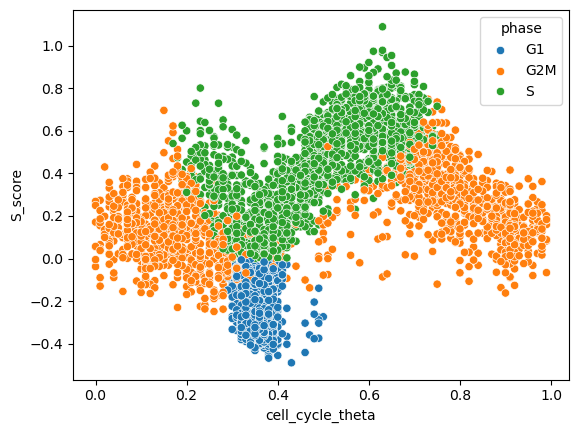

In [5]:
sns.scatterplot(
    data=adata.obs,
    x='cell_cycle_theta',
    y='S_score',
    hue='phase'
)

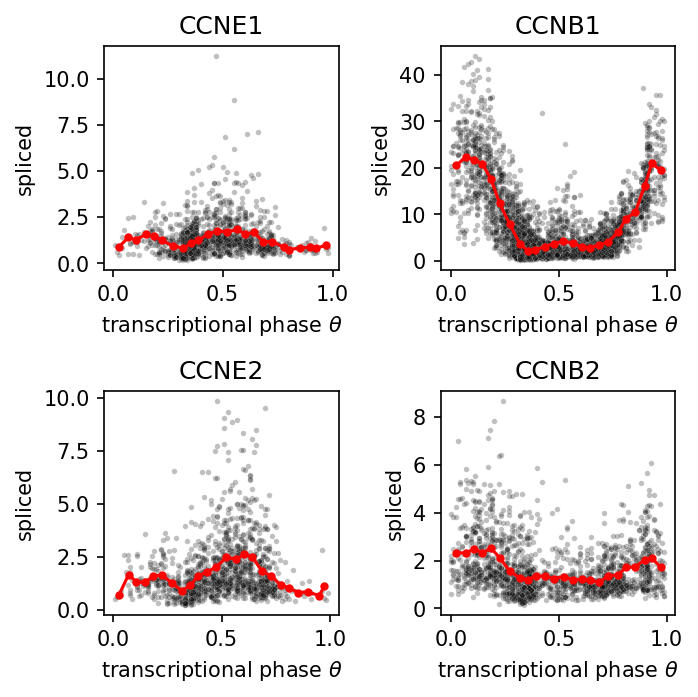

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

genes = ["CCNE1", "CCNB1", "CCNE2", "CCNB2"]

fig, axes = plt.subplots(2, 2, figsize=(4.75, 4.75), dpi=150)
axes = axes.flatten()

for i, gene in enumerate(genes):
    y = np.ravel(adata[:, gene].layers['spliced'].toarray())
    x = adata.obs['cell_cycle_theta'].values
    mask = (y > 0)
    x_masked = x[mask]
    y_masked = y[mask]

    # Scatter
    sns.scatterplot(
        x=x_masked,
        y=y_masked,
        alpha=0.25,
        s=7,
        color='k',
        ax=axes[i],
    )

    # Bin and smooth
    df = pd.DataFrame({'theta': x_masked, 'expr': y_masked})
    df = df.sort_values('theta')
    bins = np.linspace(0, 1, 25)
    df['bin'] = np.digitize(df['theta'], bins)
    df_smooth = df.groupby('bin')[['theta', 'expr']].mean()

    axes[i].plot(df_smooth['theta'], df_smooth['expr'], color='red', lw=1.5, marker=".")

    axes[i].set_title(gene)
    axes[i].set_xlabel(r"transcriptional phase $\theta$")
    axes[i].set_ylabel("spliced")

plt.tight_layout()
plt.show()


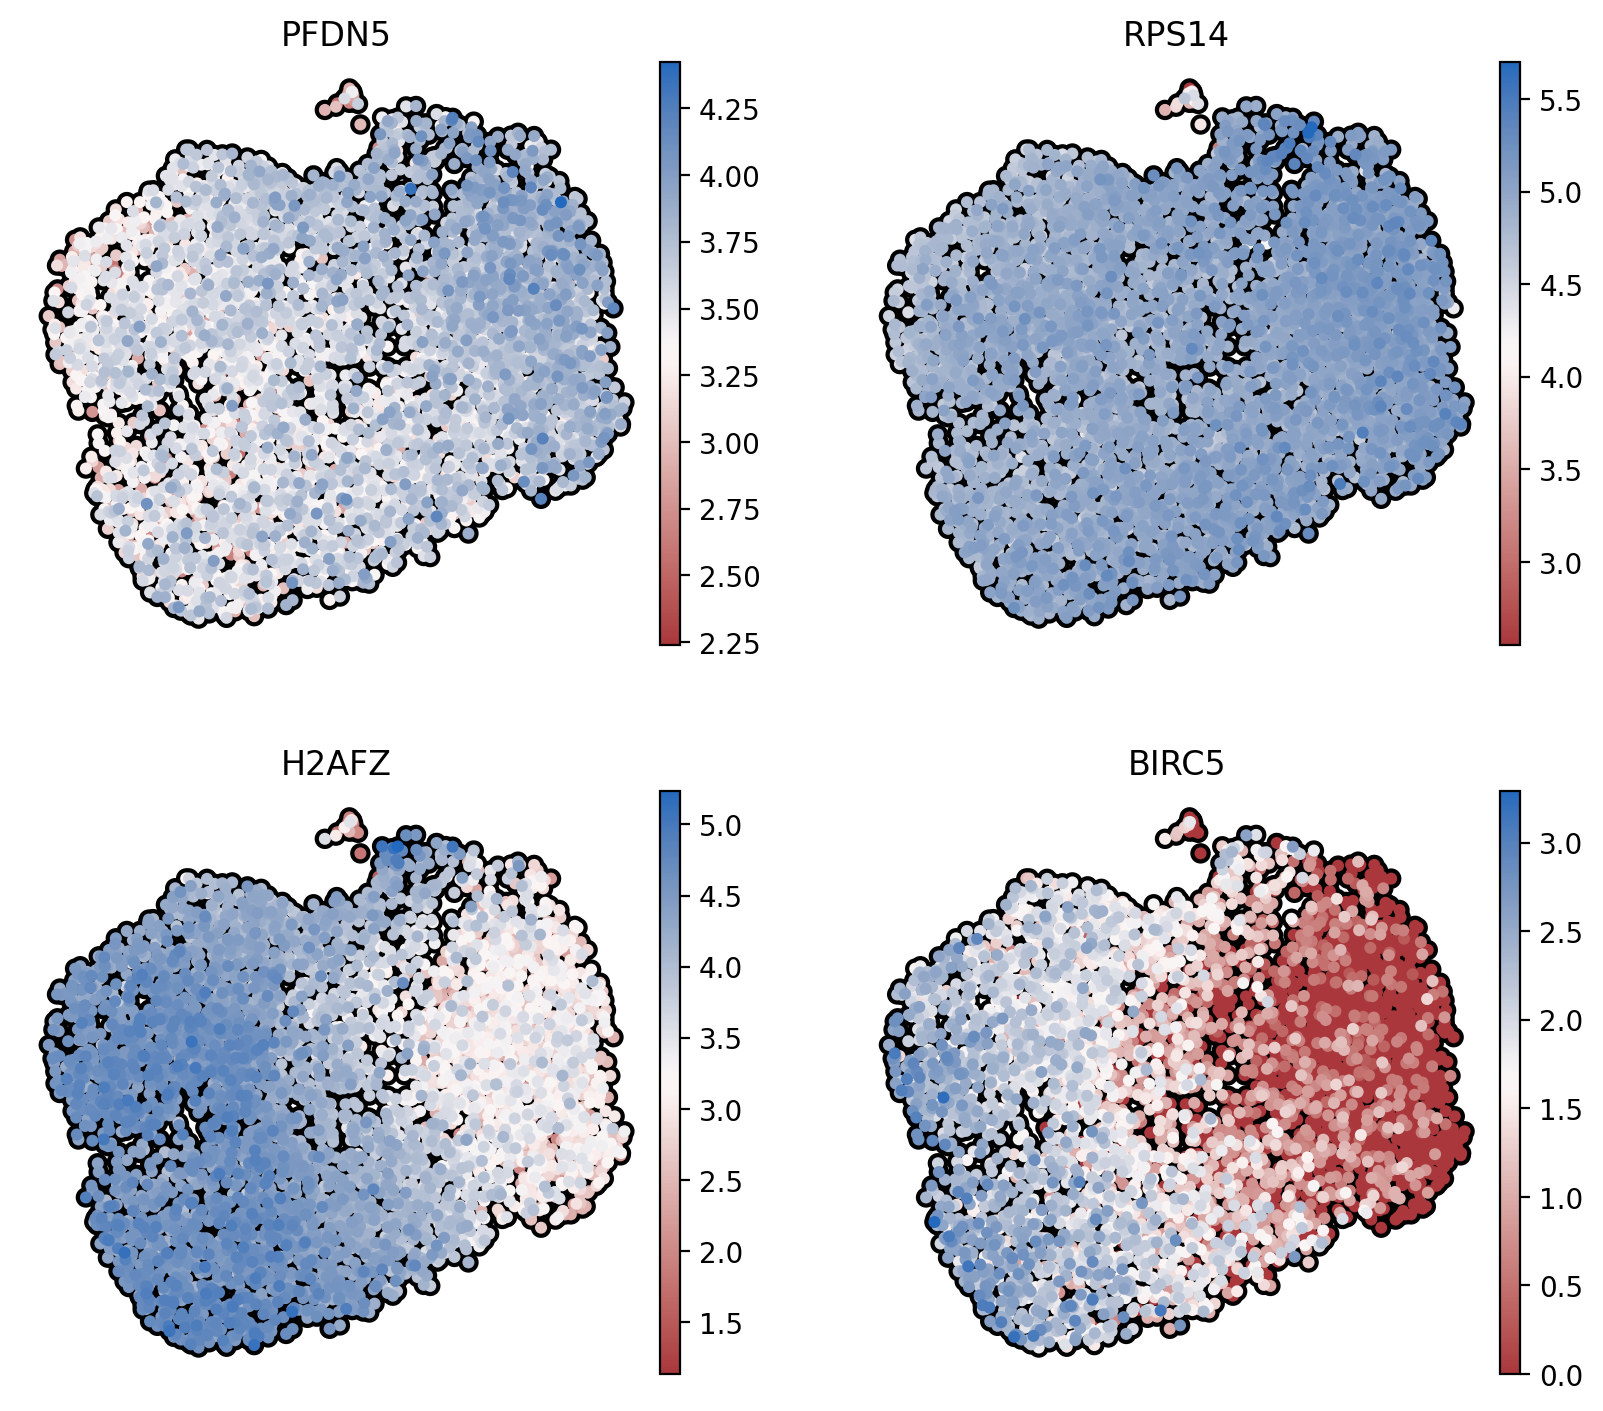

In [7]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    ncols=2,
    color=['PFDN5', 'RPS14', 'H2AFZ', 'BIRC5'],
    cmap='vlag_r',
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
)

In [8]:
# From the supplmentary figures

genes = [
    "GGH", "CDKN3", "TK1", "TMPO", "MRPL23",
    "HIST1H4C", "CUL1", "TYMS", "HAS2", "CDC20",
    "NPTX1", "RCC1", "DBI", "PSME4", "CCNB1",
    "STMN1", "CKS2", "NAPG", "S100A4", "FOXM1",
    "PLCB4", "UBE2S", "LMNB1", "USP14"
] # Genes downregulated in G0 from Coller et al

genes2 = [
    "ANLN", "MCM4", "MTCH2", "HADHB", "BIRC5",
    "PCNA", "SLC25A5", "IDH3A", "CCNA2", "RRM2",
    "H2AFZ", "KPNA2", "CCNB1", "TOP2A", "HAT1",
    "PGK1", "CCNE2", "CYCS", "CAPZA1"
] # Genes downregulated in G0 from Cheung and Rando


genes3 = [
    "PEPD", "GPR37", "LRP1", "LUM", "STOM", "MX1",
    "HYAL2", "CHN1", "PTGDS", "PROS1", "TGFBR2", "ZNF143",
    "GLB1", "MAPK7", "TFRC", "HLA-E", "AMPD3", "TRIM22",
    "NAGLU", "FGFR1", "CTSO", "PCCA", "ABCD3", "F3",
    "TIMP3", "APP", "PPP2CB", "ECH1", "PEX19", "FCGRT",
    "CDH11", "PTK7", "PTPRK", "GM2A", "SOD3", "C1R",
    "VCAM1", "LIMK1", "NMT1", "RBM51", "BMP1", "C1S",
    "LAMC1", "IL1R1", "CDR2", "NR2F1", "SPG7", "ADAR",
    "CTNNA1", "IL6", "HERC1", "HIC1", "PLAT", "STK25",
    "TNC", "BDKRB2", "UROS", "CEBPD", "PAM", "NFKB2",
    "FGD1", "AP3S1", "TPM1", "LAMP2", "MYLK", "RBP1",
    "TNFRSF1A", "CPE", "COL3A1", "NNMT", "STAT1", "EPHX1",
    "ROR1", "MYH10", "ACTA2", "RRAGA", "TCF7L2",
    "PRDX4", "SERPINF1", "TNFAIP1", "PIK3C3", "BCL6",
    "PTPRG", "ERBB2", "COL4A5", "ITGA1", "IGBP1"
] # Genes upregulated in G0 from Coller et al


genes4 = [
    "BCAS3", "PIK3R1", "BBS2", "ZBTB20",
    "GABARAPL1", "FYN", "RPS14", "PHF1",
    "ZYX", "CHKB", "IGF2R", "CTDSP1",
    "EPHX1", "PINK1", "SELENBP1", "THRA",
    "CLSTN1", "ULK2", "RNF167", "TEF",
    "GSTK1", "DNAJB9", "MAP1LC3A", "SMARCA2",
    "DDT", "PFDR5", "DICER1", "CCND3",
    "IVD", "CTSF", "FOXO3", "PDK1",
    "FHL1", "CRIM1", "EZH1",
    "GRINA", "GRB10", "PTOV1"
] # Genes upregulated in G0 from Cheung and Rando

genes5 = [
    "MXD4", "GABARAPL1", "IGFBP5", "AKR1C1", "ARMC9",
    "PDE5A", "CDC42EP2", "PNRC1", "CLIP3", "PAPPA",
    "FOS", "NEAT1", "KCNQ1OT1", "HMOX1", "CDC42EP5",
    "PLAT", "RGCC", "MIR22HG", "SLFN5", "NUPR1",
    "ADAMTS1", "CEBPD", "GDF15", "RND3", "WNT5A",
    "CRYAB", "GALNT5", "TMEM159", "FGF7", "LACTB"
] # Most upregulated genes during the transition from G1 to quiescence-like state


gene_dict = {
    "gene": (
        genes +
        genes2 +
        genes3 +
        genes4 +
        genes5
    ),
    "source": (
        ["Coller_down"] * len(genes) +
        ["Cheung_down"] * len(genes2) +
        ["Coller_up"] * len(genes3) +
        ["Cheung_up"] * len(genes4) +
        ["G1_to_G0_up"] * len(genes5)
    )
}

df = pd.DataFrame(gene_dict)
outpath = "../../../resources/quiescence_markers.csv"
df.to_csv(outpath, index=False)
df.head()

,gene,source
0,GGH,Coller_down
1,CDKN3,Coller_down
2,TK1,Coller_down
3,TMPO,Coller_down
4,MRPL23,Coller_down


In [9]:
adata.obs.columns

Index(['Clusters', '_X', '_Y', 'sample', 'n_genes', 'percent_mito', 'n_counts',
       'initial_size_spliced', 'initial_size_unspliced', 'initial_size',
       'S_score', 'G2M_score', 'phase', 'clusters_gradients', 'leiden',
       'cell_cycle_theta'],
      dtype='object')

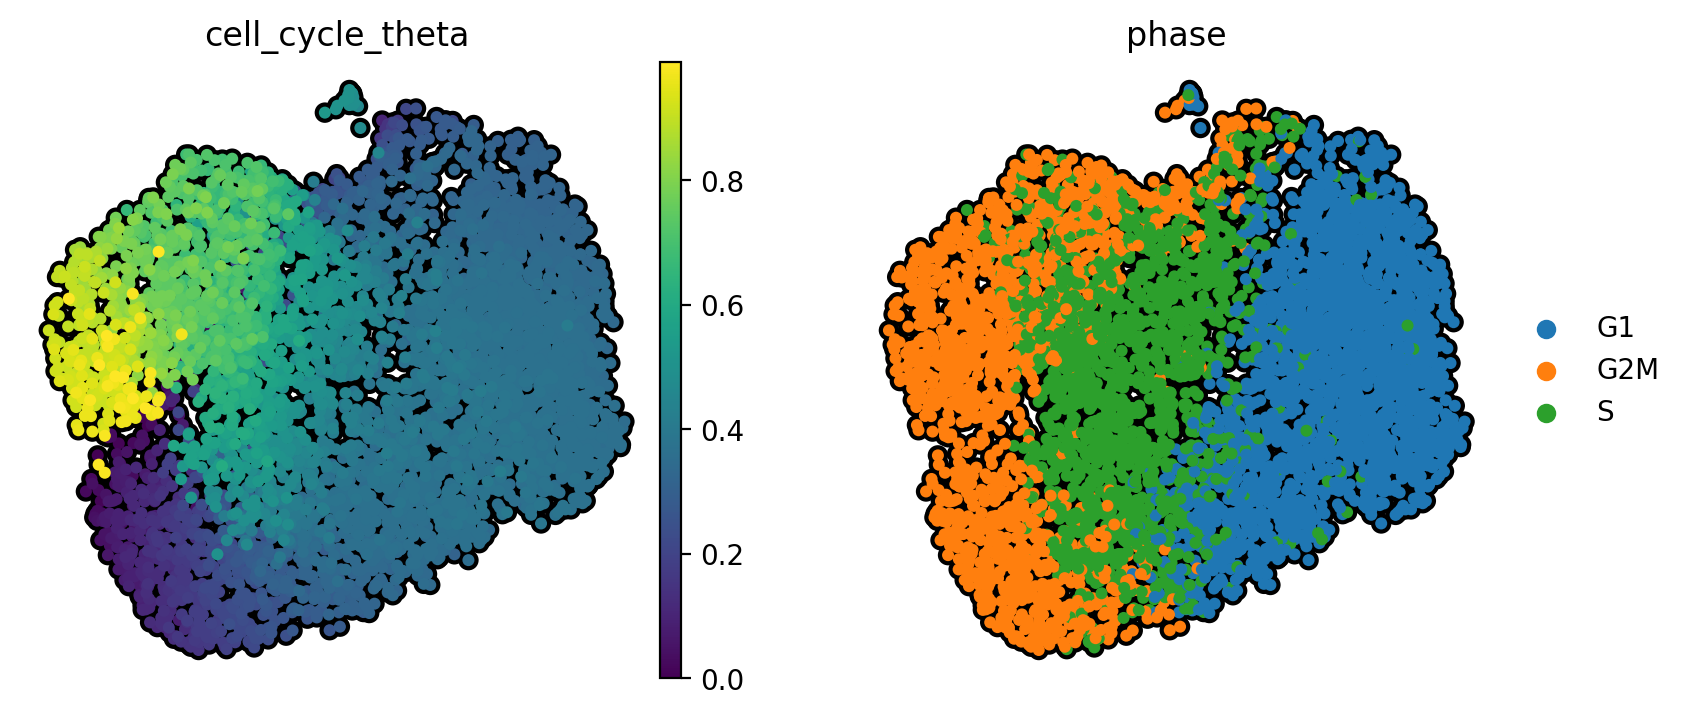

In [10]:
sc.pl.umap(
    adata,
    ncols=2,
    color=['cell_cycle_theta', 'phase'],
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
)

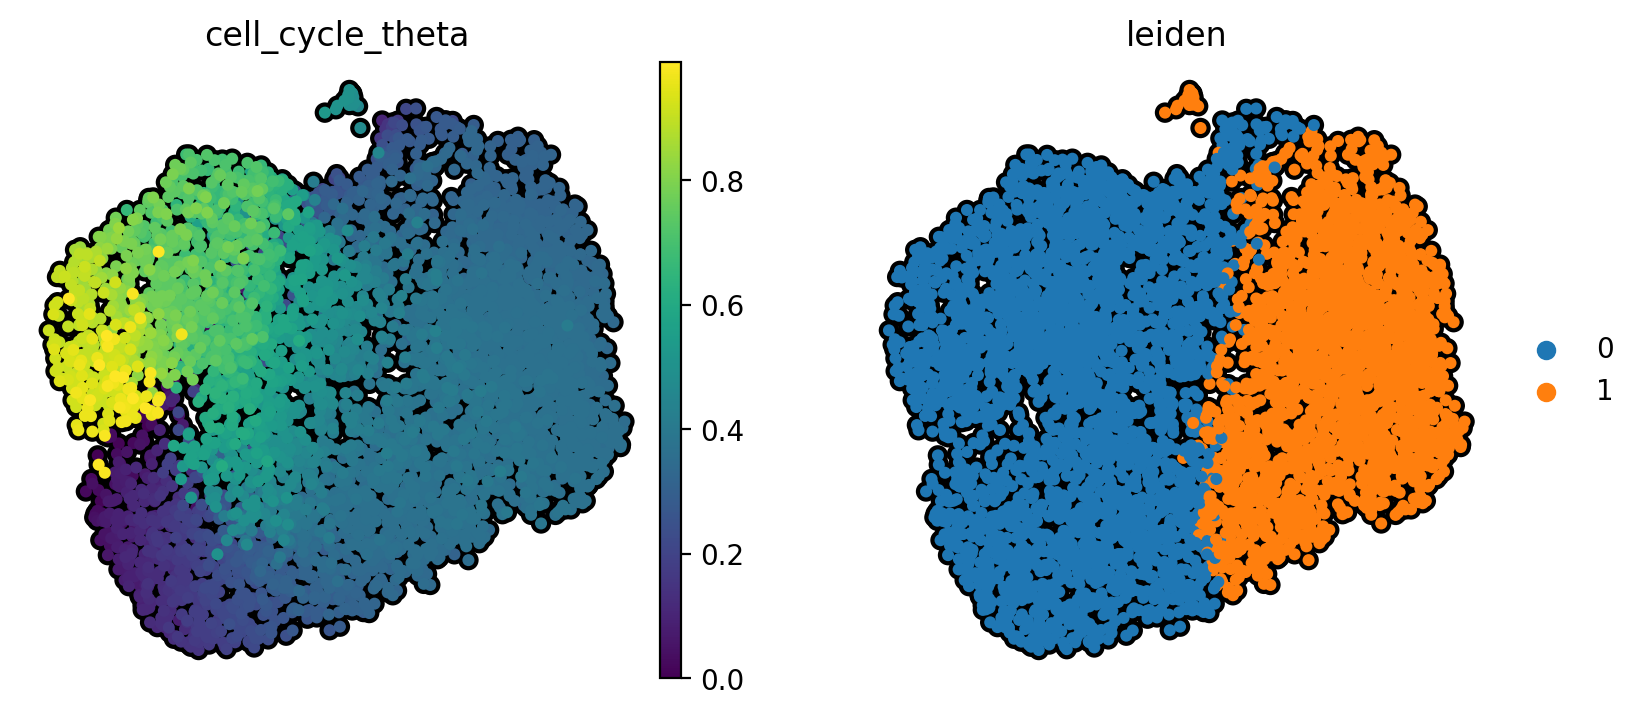

In [11]:
sc.pl.umap(
    adata,
    ncols=2,
    color=['cell_cycle_theta', 'leiden'],
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
)

# create aggregate signatures

In [12]:
adata.obs['state'] = adata.obs['phase']
adata.obs['state'] = np.where(adata.obs['leiden'] == '1', 'G0', adata.obs['state'] )
print(adata.obs['state'].value_counts().to_string())

state
G0     2281
G2M    1504
S      1463
G1      119


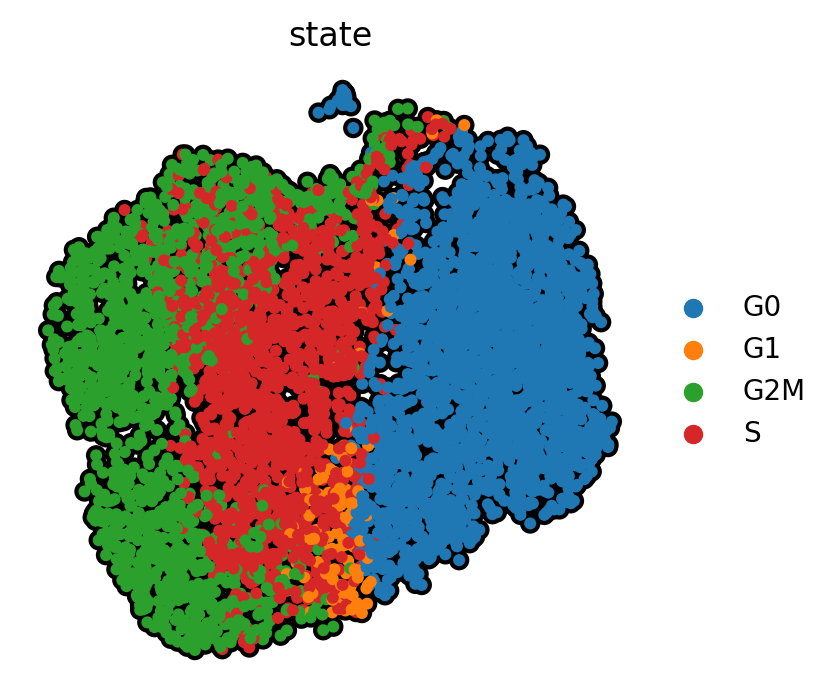

In [13]:
sc.pl.umap(
    adata,
    ncols=2,
    color=['state'],
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
)

# Aggregate and store

In [14]:
# %%time
# outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/riba_ref.h5ad"

# aggdata = sc.get.aggregate(
#     adata,
#     by='state',
#     func='sum',
#     layer='matrix',
# )

# aggdata.X = aggdata.layers['sum']
# del aggdata.layers['sum']
# print(f"{aggdata.shape=}")
# aggdata.write(outpath)
# aggdata.obs.head()